# `demo_COMMA_jiminy_example` — Jiminy Advisor demo (COMMA 2026)

Scenario: `scenarios/jiminy.yaml`

This notebook runs the classic `jiminy.yaml` scenario (child safety / access to alcohol)
with the stakeholders **Law**, **Manuf** and **Family**, using the classical two-phase
`jiminy` semantics. It shows the argumentation attack diagram, the reasoning graph, the
bidirectional variant and the causal (explanation) chain for every active action.

Active context evaluated: `w1 w2 w3 w4`.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

PATH = "../scenarios/jiminy.yaml"

def load(path=PATH):
    (pf, norms, contrariness, priorities, context_desc, norm_desc,
     contrariness_desc, priority_desc, base_priorities, meta_priorities) = load_scenario(path)
    return Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
                  contrariness_desc, priority_desc, base_priorities, meta_priorities)


## Load the scenario

In [2]:
jim = load()
print("Facts:", sorted(load_scenario(PATH)[0]))
print("Number of norms:", len(jim.norms))
print("Base priorities:", jim.base_priorities)
print("Meta priorities:", jim.meta_priorities)


[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
Facts: ['w1', 'w2', 'w3', 'w4']
Number of norms: 11
Base priorities: {}
Meta priorities: []


## Compute the two-phase `jiminy` semantics

In [3]:
context = ["w1", "w2", "w3", "w4"]
E, P, O = jim.compute_jiminy(context)
print("E (institutional facts) :", sorted(E))
print("P (permissions)          :", sorted(P))
print("O (obligations)          :", sorted(O))
print()
print("Final recommendation     :", sorted(P | O))
print("Rejected heads           :", sorted({a.hd for a in jim.generate_arguments(context)} - (E | P | O)))


E (institutional facts) : ['i1', 'i2', 'i3', 'i4', 'i5', 'w1', 'w2', 'w3', 'w4']
P (permissions)          : ['d6']
O (obligations)          : ['d3', 'd4', 'd5']

Final recommendation     : ['d3', 'd4', 'd5', 'd6']
Rejected heads           : ['d1', 'd2']


## Narrative explanation

In [4]:
accepted_heads = E | P | O
args = jim.generate_arguments(context)
accepted = [a for a in args if a.hd in accepted_heads]
rejected = [a for a in args if a.hd not in accepted_heads]
print(jim.explain(accepted, rejected, context, semantics="jiminy", debug=True))


CONTEXT ANALYSIS
------------------------------------------------------------
 - w1: child1 is in room1
 - w2: bar cabinet is in room1
 - w3: parent1 is not in room1
 - w4: parent2 is not in room1

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w1', 'w2') ⇒ i1 (Institutional fact, stakeholder=Law)  # child has access to alcohol if in same room as cabinet
 - ('w1', 'w3', 'w4') ⇒ i2 (Institutional fact, stakeholder=Manuf)  # child is unsupervised if parents absent
 - ('i1', 'i2') ⇒ i3 (Institutional fact, stakeholder=Law)  # potential risk if unsupervised and access to alcohol
 - ('i1',) ⇒ i4 (Institutional fact, stakeholder=Family)  # no clear risk if access to alcohol
 - ('i1',) ⇒ i5 (Institutional fact, stakeholder=Manuf)  # no imminent physical risk if access to alcohol
 - ('i1',) ⇒ d1 (Obligation, stakeholder=Law)  # block access to alcohol
 - ('i3',) ⇒ d2 (Obligation, stakeholder=Law)  # notify social services
 - ('i3',) ⇒ d3 (Obligation, stak

## Argumentation attack diagram (attacks and winners)

Contrariety is symmetric in this scenario, so every contrary pair is drawn as **two red
chi edges (mutual attack)**. Nodes with a **double border** are the winners under the
`jiminy` semantics (`E | P | O`).

[Visualizer] Rendering graph → demo_comma_ex_attack_winners.png


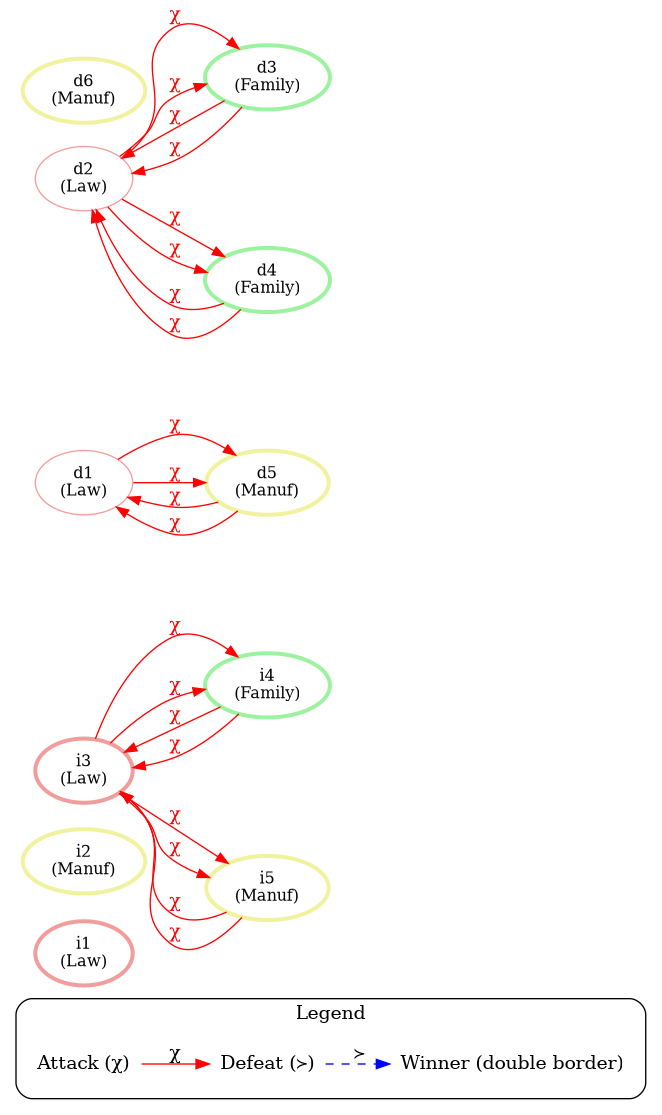

=== Winner heads (accepted) ===
['d3', 'd4', 'd5', 'd6', 'i1', 'i2', 'i3', 'i4', 'i5', 'w1', 'w2', 'w3', 'w4']
=== Attack relations (chi) present ===
  i3  <->  i4
  i3  <->  i5
  i4  <->  i3
  i5  <->  i3
  d1  <->  d5
  d2  <->  d3
  d2  <->  d4
  d3  <->  d2
  d4  <->  d2
  d5  <->  d1


In [5]:
from IPython.display import Image, display

args = jim.generate_arguments(context)
accepted_heads = E | P | O
av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in args if a.hd in accepted_heads},
               priorities=jim.priorities, contrariness=jim.contrariness)
name = "demo_comma_ex_attack_winners"
av.render(name)
display(Image(filename=f"{name}.png"))

print("=== Winner heads (accepted) ===")
print(sorted(accepted_heads))
print("=== Attack relations (chi) present ===")
for src, contraries in jim.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")


## Graphviz Advanced Exports — Reasoning graph

Reasoning dependency chain: facts (blue) -> institutional facts (green) -> decisions
(orange = accepted, gray = rejected), with the norm descriptions as labels and a color
legend embedded in the graph.

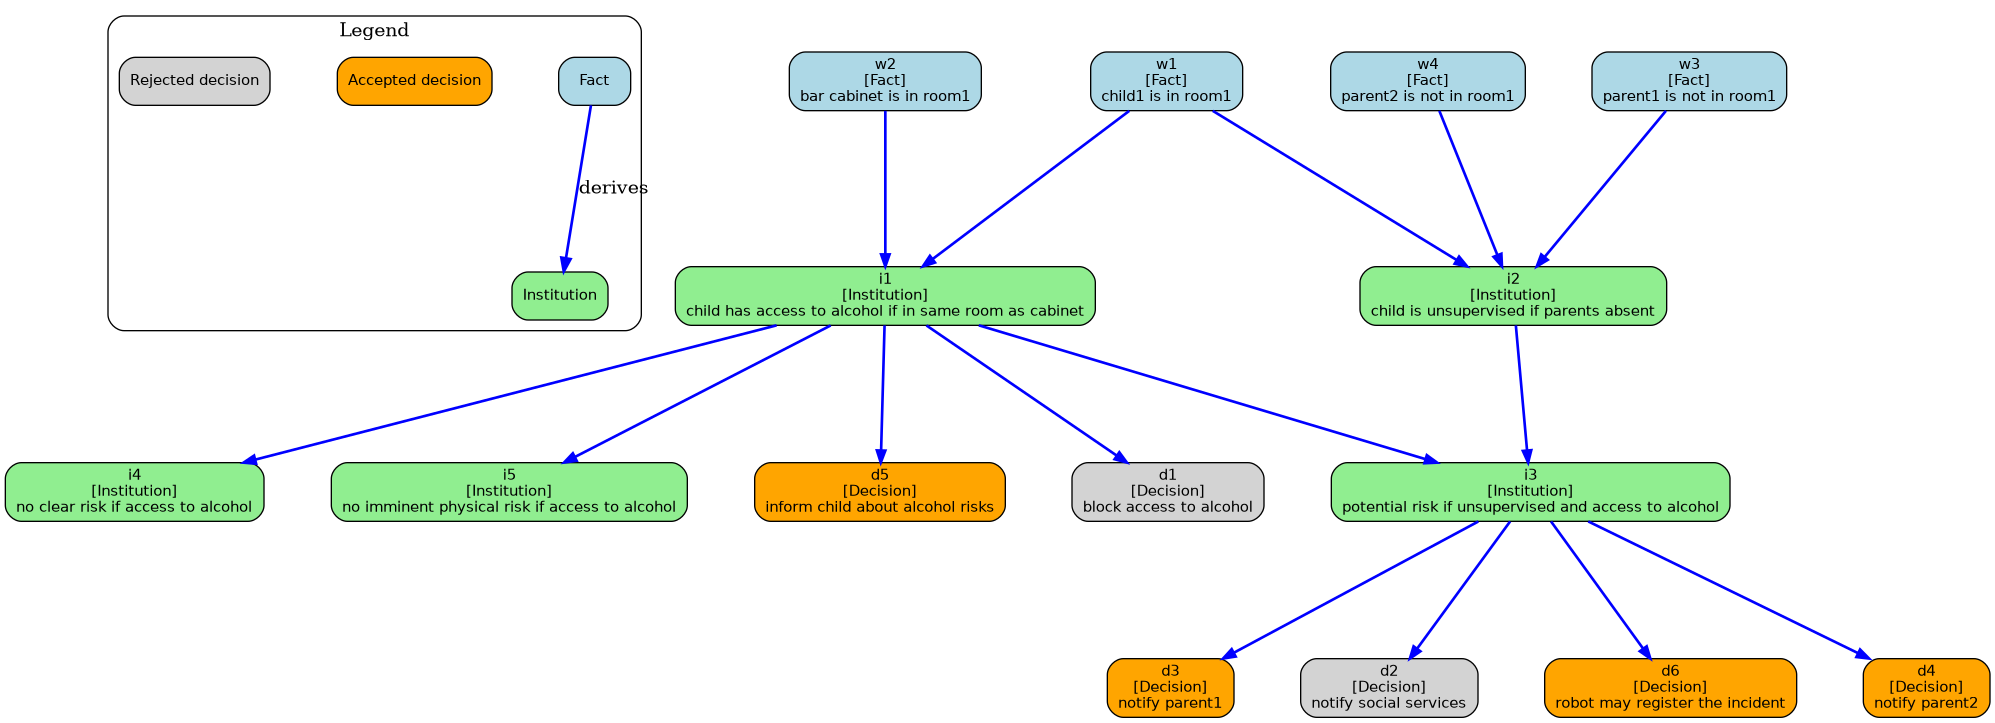

In [6]:
from graphviz import Digraph

def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_acc", "Accepted decision", fillcolor="orange")
        legend.node("lg_rej", "Rejected decision", fillcolor="lightgray")
        legend.edge("lg_fact", "lg_inst", color="blue", penwidth="2", label="derives")

    winners = {a.hd for a in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []
    for a in args_final:
        head = a.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)
        for b in getattr(a.origin_norm, "body", []):
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions:
        g.node(d, label=build_label(d), fillcolor="orange" if d in winners else "lightgray")
    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

args_final = jim.generate_arguments(context)
winners = {a.hd for a in args_final if a.hd in (E | P | O)}
accepted = [a for a in args_final if a.hd in winners]

display(Image(filename=export_reasoning_graph("demo_comma_ex_reasoning")))


## Comparison: `compute_jiminy` vs `compute_jiminy_bidirectional`

The standard two-phase procedure is compared with the **bidirectional** variant. In this
scenario no accepted decision attacks another accepted conclusion, so both variants return
the same extension.

In [7]:
E1, P1, O1 = jim.compute_jiminy(context)
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)

print("standard       : O =", sorted(O1), "| P =", sorted(P1))
print("bidirectional  : O =", sorted(O2), "| P =", sorted(P2))
print()
print("identical ->", sorted(E1) == sorted(E2) and sorted(P1) == sorted(P2) and sorted(O1) == sorted(O2))


standard       : O = ['d3', 'd4', 'd5'] | P = ['d6']
bidirectional  : O = ['d3', 'd4', 'd5'] | P = ['d6']

identical -> True


## Bidirectional variant — updated graph

Here both variants agree, so the winners are unchanged: the permissions `d6` and the
obligations `d3`, `d4`, `d5`.

[Visualizer] Rendering graph → demo_comma_ex_bidir_attack_winners.png


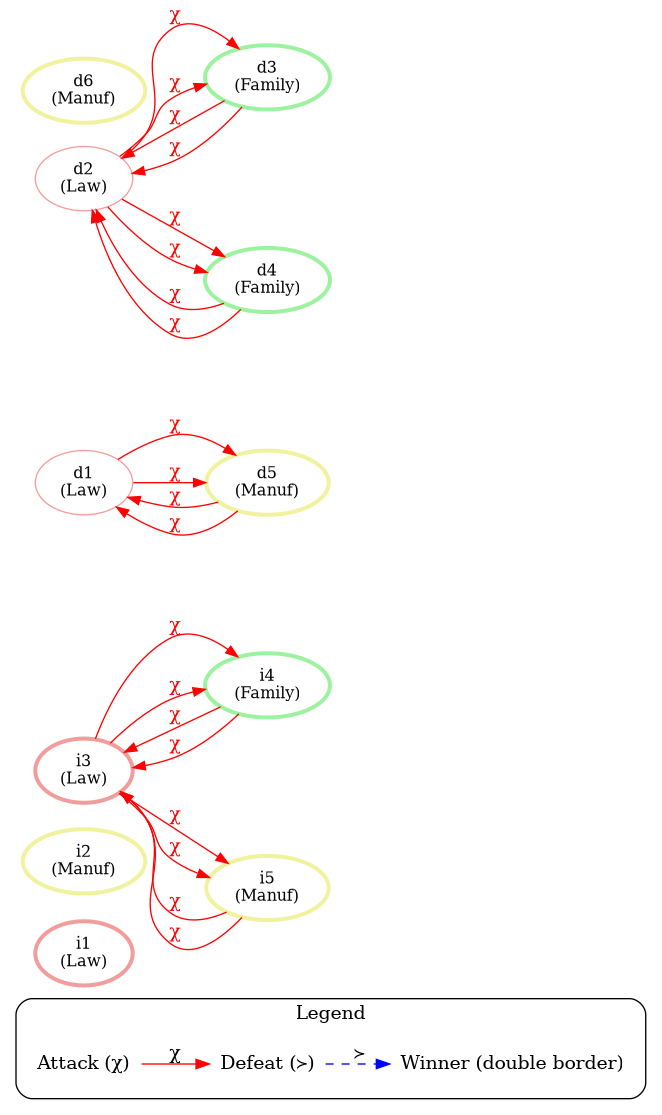

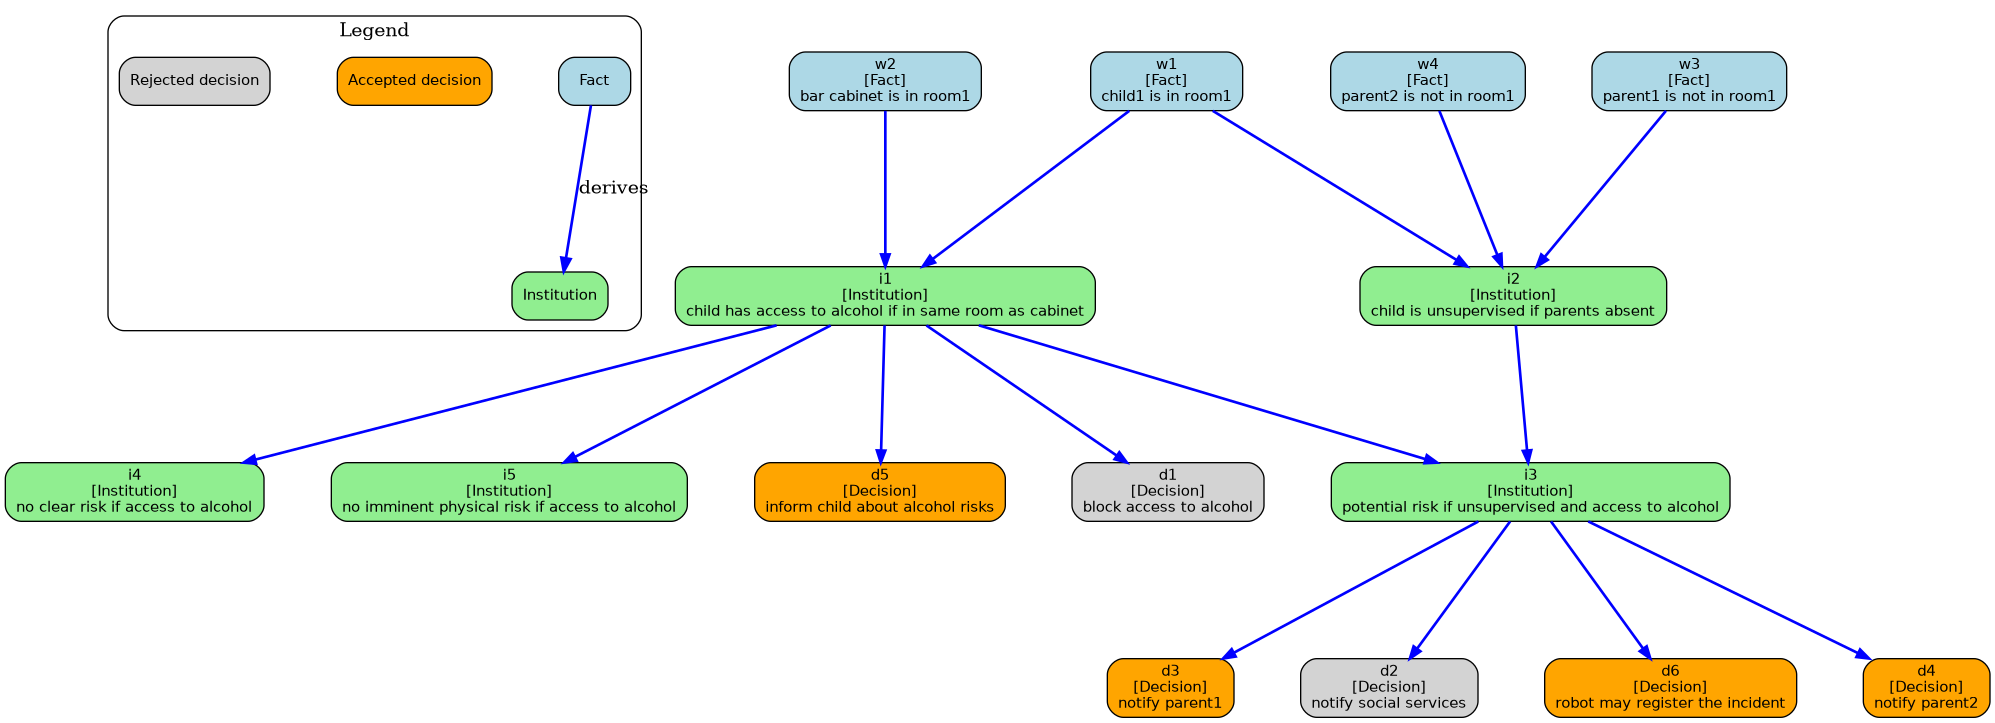

=== Bidirectional winner heads ===
['d3', 'd4', 'd5', 'd6', 'i1', 'i2', 'i3', 'i4', 'i5', 'w1', 'w2', 'w3', 'w4']


In [8]:
from IPython.display import Image, display

E2, P2, O2 = jim.compute_jiminy_bidirectional(context)
bidir_heads = E2 | P2 | O2
args = jim.generate_arguments(context)

av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in args if a.hd in bidir_heads},
               priorities=jim.priorities, contrariness=jim.contrariness)
av.render("demo_comma_ex_bidir_attack_winners")
display(Image(filename="demo_comma_ex_bidir_attack_winners.png"))

args_final = jim.generate_arguments(context)
winners = {a.hd for a in args_final if a.hd in bidir_heads}
accepted = [a for a in args_final if a.hd in winners]
display(Image(filename=export_reasoning_graph("demo_comma_ex_bidir_reasoning")))

print("=== Bidirectional winner heads ===")
print(sorted(bidir_heads))


### Narrative explanation (bidirectional)

Narrative explanation for the `compute_jiminy_bidirectional` result. Since both variants
agree in this scenario, the accepted and rejected decisions are the same as before.

In [9]:
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)
bidir_heads = E2 | P2 | O2
args = jim.generate_arguments(context)
accepted = [a for a in args if a.hd in bidir_heads]
rejected = [a for a in args if a.hd not in bidir_heads]

print(jim.explain(accepted, rejected, context, semantics="jiminy", debug=True))


CONTEXT ANALYSIS
------------------------------------------------------------
 - w1: child1 is in room1
 - w2: bar cabinet is in room1
 - w3: parent1 is not in room1
 - w4: parent2 is not in room1

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w1', 'w2') ⇒ i1 (Institutional fact, stakeholder=Law)  # child has access to alcohol if in same room as cabinet
 - ('w1', 'w3', 'w4') ⇒ i2 (Institutional fact, stakeholder=Manuf)  # child is unsupervised if parents absent
 - ('i1', 'i2') ⇒ i3 (Institutional fact, stakeholder=Law)  # potential risk if unsupervised and access to alcohol
 - ('i1',) ⇒ i4 (Institutional fact, stakeholder=Family)  # no clear risk if access to alcohol
 - ('i1',) ⇒ i5 (Institutional fact, stakeholder=Manuf)  # no imminent physical risk if access to alcohol
 - ('i1',) ⇒ d1 (Obligation, stakeholder=Law)  # block access to alcohol
 - ('i3',) ⇒ d2 (Obligation, stakeholder=Law)  # notify social services
 - ('i3',) ⇒ d3 (Obligation, stak

## Causal explanation — per-action motivation

For every active action this shows the **causal chain** of motivation: the brute facts and
institutional facts that activate the rule, the rule itself and its issuing stakeholder.
Rejected actions are explained by the active conclusion they conflict with. Both the
standard and the bidirectional result are shown.

In [10]:
# Standard
E, P, O = jim.compute_jiminy(context)
acc = [a for a in jim.generate_arguments(context) if a.hd in (E | P | O)]
rej = [a for a in jim.generate_arguments(context) if a.hd not in (E | P | O)]
print("########## STANDARD ##########")
print(jim.explain_causal(acc, rej, context))

# Bidirectional
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)
acc2 = [a for a in jim.generate_arguments(context) if a.hd in (E2 | P2 | O2)]
rej2 = [a for a in jim.generate_arguments(context) if a.hd not in (E2 | P2 | O2)]
print()
print("########## BIDIRECTIONAL ##########")
print(jim.explain_causal(acc2, rej2, context))


########## STANDARD ##########
CAUSAL EXPLANATION (jiminy)
------------------------------------------------------------

ACTIVE ACTIONS AND WHY THEY ARE MOTIVATED

* d3 (obligation, rule r3, stakeholder Family)
  rule: ('i3',) =>^r_Family d3
  why: because i3 (potential risk if unsupervised and access to alcohol) = institutional fact derived by rule c3 (Law) from [i1 (child has access to alcohol if in same room as cabinet) = institutional fact derived by rule c1 (Law) from [w1 (child1 is in room1), w2 (bar cabinet is in room1)], i2 (child is unsupervised if parents absent) = institutional fact derived by rule c2 (Manuf) from [w1 (child1 is in room1), w3 (parent1 is not in room1), w4 (parent2 is not in room1)]]

* d4 (obligation, rule r4, stakeholder Family)
  rule: ('i3',) =>^r_Family d4
  why: because i3 (potential risk if unsupervised and access to alcohol) = institutional fact derived by rule c3 (Law) from [i1 (child has access to alcohol if in same room as cabinet) = institutional 

## Causal chain drawn per active action

Each active action is drawn as a **causal derivation graph**: brute facts (blue), the
institutional facts they derive (green) and the deontic action (orange for obligation,
khaki for permission), with the edges labelled by the rule that produces each step.

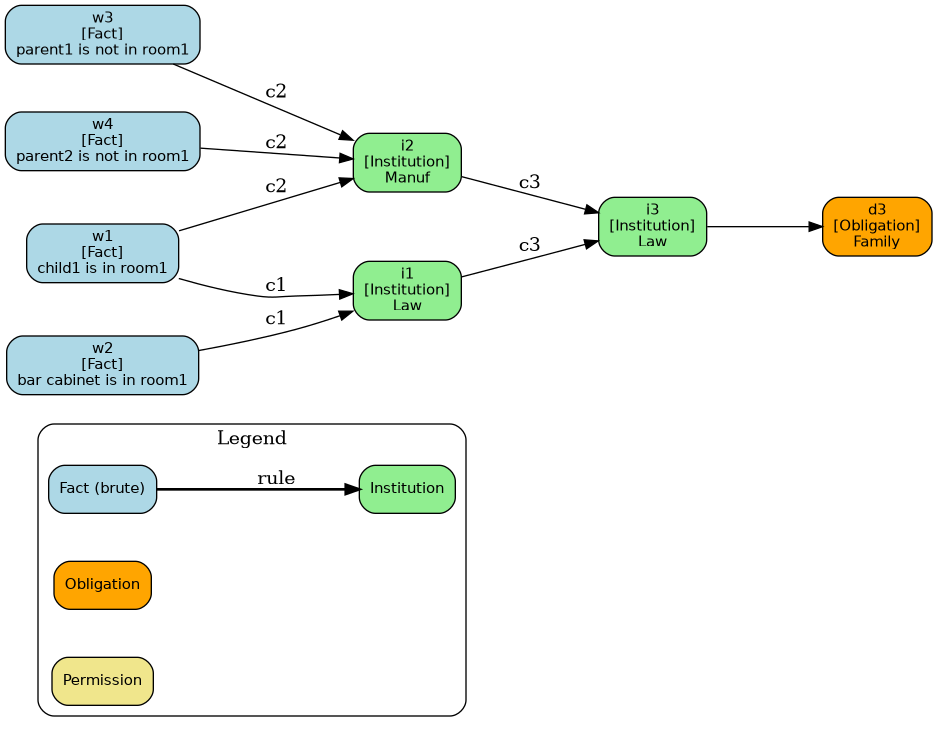

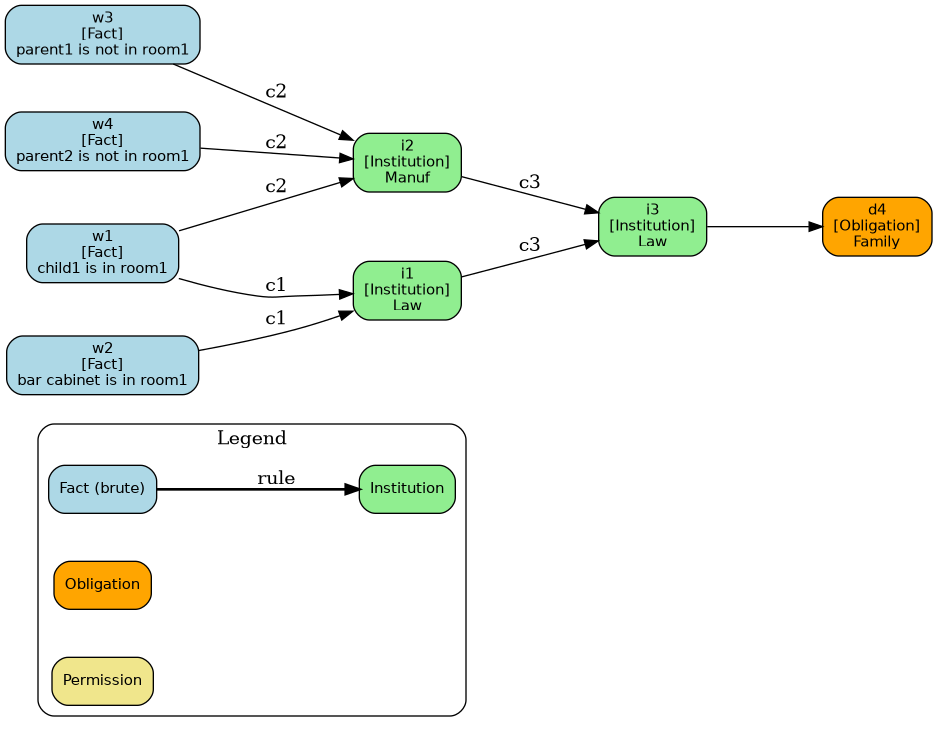

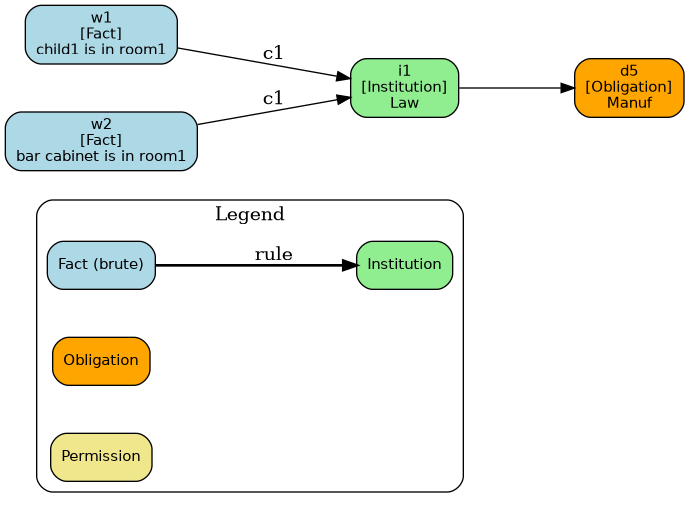

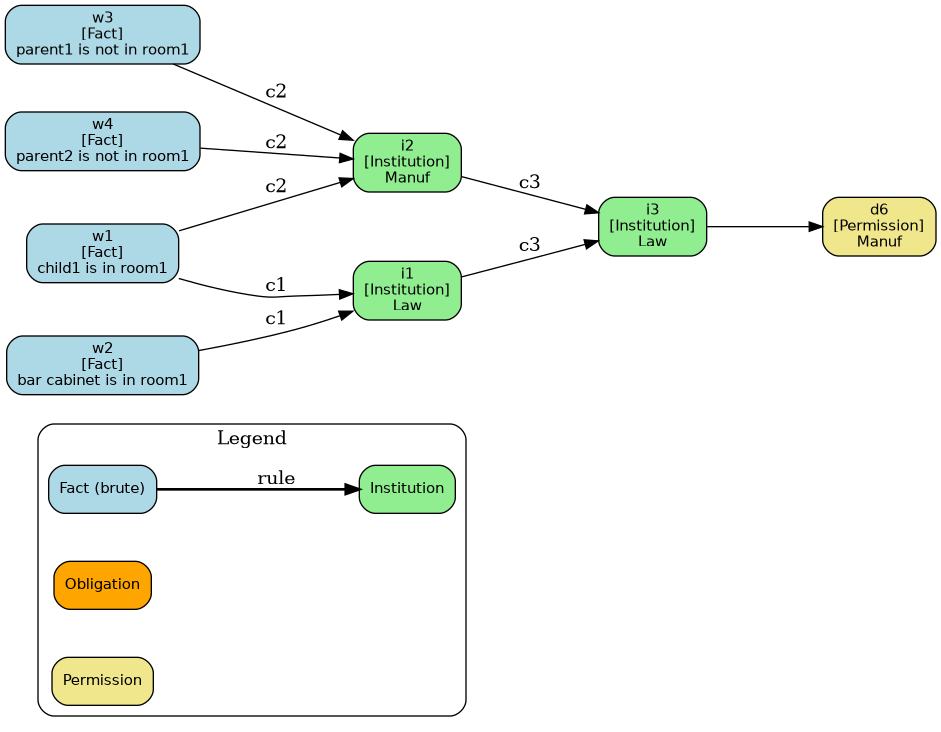

Drawn causal chains for: ['d3', 'd4', 'd5', 'd6']


In [11]:
from graphviz import Digraph
from IPython.display import Image, display

KIND = {"c": ("Institution", "lightgreen"), "r": ("Obligation", "orange"), "p": ("Permission", "khaki")}


def draw_causal_chain(argument, filename):
    """Draw the causal chain that motivates a given accepted argument."""
    g = Digraph(f"causal_{argument.hd}", format="png")
    g.attr(rankdir="LR", splines="spline", ranksep="1.2", nodesep="0.5")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact (brute)", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_obl", "Obligation", fillcolor="orange")
        legend.node("lg_perm", "Permission", fillcolor="khaki")
        legend.edge("lg_fact", "lg_inst", label="rule", penwidth="2")

    def visit(atom):
        producers = [n for n in jim.norms if n.head == atom]
        if not producers:
            g.node(atom, f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}", fillcolor="lightblue")
            return
        n = producers[0]
        kind, fc = KIND[n.tau]
        g.node(atom, f"{atom}\n[{kind}]\n{n.stakeholder}", fillcolor=fc)
        for b in n.body:
            visit(b)
            g.edge(b, atom, label=n.id if n.tau == "c" else "")

    visit(argument.hd)
    g.render(filename, cleanup=True)
    return f"{filename}.png"


edited = []
for head in sorted({a.hd for a in acc if not a.hd.startswith("i")}):
    arg = next(a for a in acc if a.hd == head)
    path = draw_causal_chain(arg, f"comma_ex_chain_{head}")
    edited.append(head)
    display(Image(filename=path))

print("Drawn causal chains for:", edited)


## Why is `d1` (block access to alcohol) rejected? How to make it win

In the result above the recommendation is `d5` (inform child about risks) and not
`d1` (block access to alcohol), even though both are issued from the same institutional
fact `i1` (`d1` comes from rule `r1`, `d5` from `r5`).

### The conflict

`d1` and `d5` are contrary (they **attack** each other):

- `d1` --opposes--> `d5`  (Law: block access to alcohol)
- `d5` --opposes--> `d1`  (Manuf: inform child about alcohol risks)

In phase 2 of the `jiminy` procedure only **one** of the two (or neither) survives,
because a rule whose head is contrary to an already-active element is dropped.

### Why `d5` wins by default

This scenario carries no priorities (`priorities: {}`), and in the classical two-phase
`jiminy` semantics the **regulative `priorities` dict is not used** at all. Instead, the
choice is driven by **stakeholder priority** (`base_priorities` / `meta_priorities`), and
when all stakeholders are tied the tie is broken by the rule **id** (`max` on the id
string, so `r5 > r1`). That is why `d5` is selected and `d1` is dropped.

### How to make `d1` win

Give the **Law** stakeholder a higher priority than **Manuf** (and Family). Add a
`base_priorities` section to the scenario:

```yaml
base_priorities:
  Law: 10
  Manuf: 5
  Family: 5
```

With this, `Law` outranks `Manuf`, so `r1` (`d1`) is selected over `r5` (`d5`). As a side
effect, the other Law rule `r2` (`d2`, notify social services) also wins over the Family
rules `d3`/`d4`.

A more targeted alternative that only escalates Law when the risk institutional fact `i3`
is active is a contextual `meta_priorities` rule:

```yaml
meta_priorities:
  - if: i3
    stakeholder: Law
    value: 10
```

The cell below re-runs the scenario with `base_priorities: Law > Manuf` and shows the
recommendation switching to `d1`.


In [12]:
# Re-run the scenario giving Law the highest priority
from jiminy.yaml_loader import load_scenario
from jiminy.engine import Jiminy

path = "../scenarios/jiminy.yaml"
(pf, norms, contr, prio, cd, nd, cdd, pd, bp, mp) = load_scenario(path)
bp = {"Law": 10, "Manuf": 5, "Family": 5}   # Law outranks Manuf & Family

jim2 = Jiminy(norms, contr, prio, cd, nd, cdd, pd, bp, mp)
E2, P2, O2 = jim2.compute_jiminy(context)
print("E :", sorted(E2))
print("P :", sorted(P2))
print("O :", sorted(O2))
print()
print("block access to alcohol (d1) accepted ->", "d1" in O2)
print("inform child about risks (d5) rejected ->", "d5" not in O2)


[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
E : ['i1', 'i2', 'i3', 'i4', 'i5', 'w1', 'w2', 'w3', 'w4']
P : ['d6']
O : ['d1', 'd2']

block access to alcohol (d1) accepted -> True
inform child about risks (d5) rejected -> True
